# Customer Retention Intelligence
## 03 — Model Explainability

### Goal

Understand which customer characteristics drive churn predictions and compare the behavior of the Logistic Regression baseline with the tuned Gradient Boosting model.

### Workflow

1. Recreate the modeling dataset and train-test split.
2. Rebuild the selected models.
3. Examine Logistic Regression coefficients.
4. Examine Gradient Boosting feature importance.
5. Compare the most influential churn drivers.
6. Explore customer-level explanations for high-risk predictions.

In [1]:
from pathlib import Path
import pandas as pd

from sklearn.model_selection import train_test_split

DATA_PATH = Path("../data/processed/telco_churn_clean.csv")

df = pd.read_csv(DATA_PATH)

X = df.drop(columns=["customerID", "Churn"])
y = df["Churn"].map({"No": 0, "Yes": 1})

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [2]:
numeric_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

binary_features = [
    "SeniorCitizen"
]

categorical_features = [
    col for col in X.columns
    if col not in numeric_features + binary_features
]

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

In [4]:
logistic_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("binary", "passthrough", binary_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("binary", "passthrough", binary_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [5]:
logistic_model = Pipeline([
    ("preprocessor", logistic_preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

gradient_boosting_model = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", GradientBoostingClassifier(
        learning_rate=0.05,
        max_depth=2,
        min_samples_leaf=20,
        n_estimators=200,
        random_state=42
    ))
])

In [6]:
logistic_model.fit(X_train, y_train)
gradient_boosting_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('binary', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remai

In [7]:
logistic_feature_names = (
    logistic_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

logistic_feature_names[:10]

array(['num__tenure', 'num__MonthlyCharges', 'num__TotalCharges',
       'binary__SeniorCitizen', 'cat__gender_Female', 'cat__gender_Male',
       'cat__Partner_No', 'cat__Partner_Yes', 'cat__Dependents_No',
       'cat__Dependents_Yes'], dtype=object)

In [8]:
logistic_coefficients = (
    logistic_model
    .named_steps["model"]
    .coef_[0]
)

logistic_importance = pd.DataFrame({
    "Feature": logistic_feature_names,
    "Coefficient": logistic_coefficients
})

logistic_importance["AbsoluteCoefficient"] = (
    logistic_importance["Coefficient"].abs()
)

logistic_importance = logistic_importance.sort_values(
    "AbsoluteCoefficient",
    ascending=False
)

logistic_importance.head(15)

,Feature,Coefficient,AbsoluteCoefficient
0,num__tenure,-1.249501,1.249501
38,cat__Contract_Two year,-0.770715,0.770715
15,cat__InternetService_DSL,-0.660859,0.660859
16,cat__InternetService_Fiber optic,0.651066,0.651066
1,num__MonthlyCharges,-0.620723,0.620723
36,cat__Contract_Month-to-month,0.576117,0.576117
2,num__TotalCharges,0.525363,0.525363
39,cat__PaperlessBilling_No,-0.343703,0.343703
25,cat__DeviceProtection_No internet service,-0.306057,0.306057
17,cat__InternetService_No,-0.306057,0.306057


In [11]:
top_churn_drivers = (
    logistic_importance
    .sort_values("Coefficient", ascending=False)
    .head(10)
)

top_retention_drivers = (
    logistic_importance
    .sort_values("Coefficient")
    .head(10)
)

print("=== TOP CHURN DRIVERS ===")
display(top_churn_drivers)

print("=== TOP RETENTION DRIVERS ===")
display(top_retention_drivers)

=== TOP CHURN DRIVERS ===


,Feature,Coefficient,AbsoluteCoefficient
16,cat__InternetService_Fiber optic,0.651066,0.651066
36,cat__Contract_Month-to-month,0.576117,0.576117
2,num__TotalCharges,0.525363,0.525363
32,cat__StreamingTV_Yes,0.208361,0.208361
35,cat__StreamingMovies_Yes,0.208304,0.208304
43,cat__PaymentMethod_Electronic check,0.197795,0.197795
18,cat__OnlineSecurity_No,0.156808,0.156808
3,binary__SeniorCitizen,0.144545,0.144545
27,cat__TechSupport_No,0.131505,0.131505
14,cat__MultipleLines_Yes,0.109912,0.109912


=== TOP RETENTION DRIVERS ===


,Feature,Coefficient,AbsoluteCoefficient
0,num__tenure,-1.249501,1.249501
38,cat__Contract_Two year,-0.770715,0.770715
15,cat__InternetService_DSL,-0.660859,0.660859
1,num__MonthlyCharges,-0.620723,0.620723
39,cat__PaperlessBilling_No,-0.343703,0.343703
19,cat__OnlineSecurity_No internet service,-0.306057,0.306057
17,cat__InternetService_No,-0.306057,0.306057
25,cat__DeviceProtection_No internet service,-0.306057,0.306057
31,cat__StreamingTV_No internet service,-0.306057,0.306057
22,cat__OnlineBackup_No internet service,-0.306057,0.306057


### Logistic Regression Interpretation

The Logistic Regression coefficients largely support the patterns observed during EDA.

Longer customer tenure and two-year contracts are strongly associated with lower churn risk, while month-to-month contracts and fiber optic service are associated with higher churn risk.

Some numerical coefficients, particularly `MonthlyCharges` and `TotalCharges`, should be interpreted carefully because these variables are correlated with tenure and with one another. The coefficients represent relationships after accounting for the other features in the model rather than isolated causal effects.

Several "No internet service" features also contain overlapping information, resulting in very similar coefficients.

In [12]:
gb_feature_names = (
    gradient_boosting_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

gb_feature_importances = (
    gradient_boosting_model
    .named_steps["model"]
    .feature_importances_
)

gb_importance = pd.DataFrame({
    "Feature": gb_feature_names,
    "Importance": gb_feature_importances
}).sort_values(
    "Importance",
    ascending=False
)

gb_importance.head(15)

,Feature,Importance
36,cat__Contract_Month-to-month,0.357043
0,num__tenure,0.178890
16,cat__InternetService_Fiber optic,0.127607
18,cat__OnlineSecurity_No,0.079980
27,cat__TechSupport_No,0.059357
43,cat__PaymentMethod_Electronic check,0.055155
1,num__MonthlyCharges,0.039901
2,num__TotalCharges,0.038672
12,cat__MultipleLines_No,0.010797
38,cat__Contract_Two year,0.010122


### Gradient Boosting Feature Importance

Gradient Boosting identifies **month-to-month contracts** as the strongest predictive feature, followed by **customer tenure** and **fiber optic internet service**.

Lack of online security, lack of technical support, and electronic check payments also contribute meaningfully to churn predictions.

These findings are broadly consistent with both the exploratory analysis and Logistic Regression results. However, Gradient Boosting feature importance measures how useful a feature is for prediction, not whether the feature increases or decreases churn risk.

Correlated or redundant features may also receive lower importance when another feature already captures similar information.

In [13]:
import shap
import numpy as np

In [14]:
gb_preprocessor = gradient_boosting_model.named_steps["preprocessor"]
gb_model = gradient_boosting_model.named_steps["model"]

X_test_transformed = gb_preprocessor.transform(X_test)
gb_feature_names = gb_preprocessor.get_feature_names_out()

if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

X_test_transformed = pd.DataFrame(
    X_test_transformed,
    columns=gb_feature_names,
    index=X_test.index
)

In [15]:
gb_probabilities = gradient_boosting_model.predict_proba(X_test)[:, 1]

high_risk_position = np.argmax(gb_probabilities)
high_risk_index = X_test.index[high_risk_position]

print(f"Customer index: {high_risk_index}")
print(f"Predicted churn probability: {gb_probabilities[high_risk_position]:.3f}")
print(f"Actual churn: {y_test.loc[high_risk_index]}")

display(X_test.loc[[high_risk_index]])

Customer index: 3380
Predicted churn probability: 0.915
Actual churn: 1


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
3380,Male,1,Yes,No,1,Yes,Yes,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,95.1,95.1


In [16]:
explainer = shap.TreeExplainer(gb_model)

shap_values = explainer(X_test_transformed)

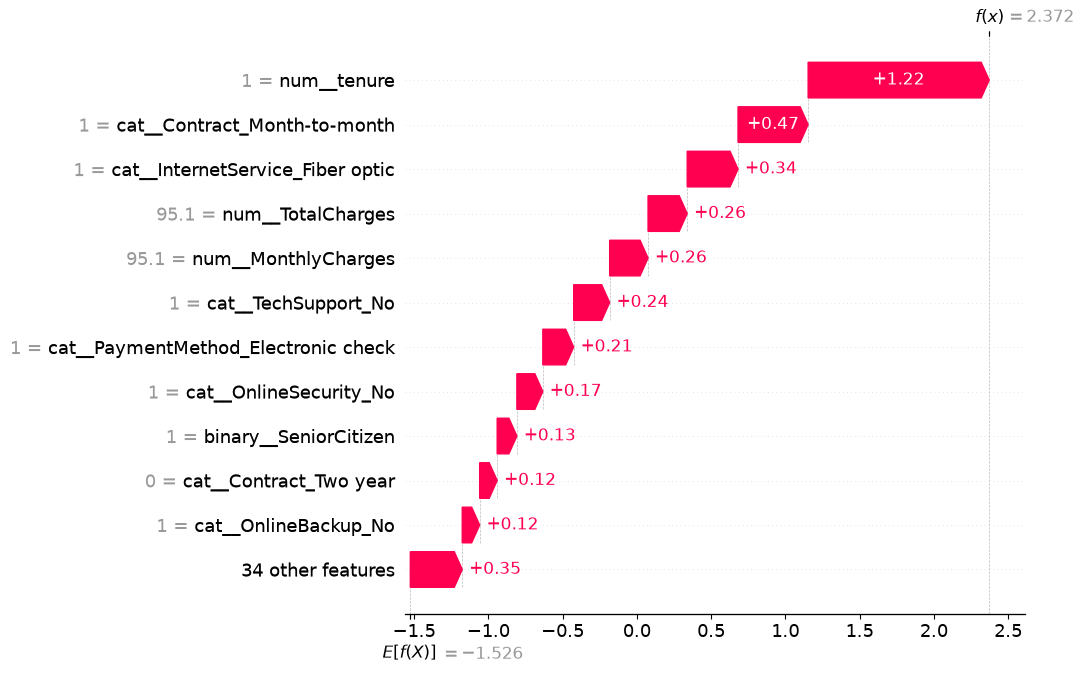

In [17]:
shap.plots.waterfall(
    shap_values[high_risk_position],
    max_display=12
)

### Individual Customer Explanation

For this high-risk customer, the model predicts approximately a **91% churn probability**.

The strongest contributor is the customer's extremely short tenure of only one month. A month-to-month contract, fiber optic service, high monthly charges, lack of technical support and online security, and electronic check payments further increase the predicted churn risk.

The customer-level explanation is consistent with the global patterns identified during EDA and feature-importance analysis, demonstrating how SHAP can translate the model's prediction into an actionable customer risk profile.

In [18]:
from pathlib import Path
import joblib

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True,exist_ok=True)

MODEL_PATH = MODEL_DIR / "churn_gradient_boosting.joblib"

joblib.dump(
    gradient_boosting_model,
    MODEL_PATH
)

print(f"Model saved to: {MODEL_PATH}")

Model saved to: ..\models\churn_gradient_boosting.joblib
